# Tree node optimization
- In this notebook, we work with the pre-processed insurance data and we **optimize split** of one particular node.
- Namely for the smokers_yes == 1 node.
- The task is to **find optimal split** using the following 3 numerical features: **bmi, age and numer of children.**
- Intentionally, we are avoiding categorical variables as these are slightly more complicated (but not that much...)


## Data
Source: [https://www.kaggle.com/datasets/mirichoi0218/insurance]

Individual medical costs billed by health insurance

EDA: e.g [https://datauab.github.io/medical_insurance/]


In [1]:
import pandas as pd #data frames and other stuff
import numpy as np #arrays and statistical functions
import matplotlib.pyplot as plt #basic graphs
import pickle #load data in binary format

In [3]:
import gdown
#In colab, you need to download the file first and save it locally
file_id = '1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9' #insurance.pkl
file_path = 'insurance_train_test.pkl'
gdown.download('https://drive.google.com/uc?id={}'.format(file_id), file_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1ZHg2xs5ekH1XKzcvbJBkkqcHIl4J9mD9
To: /content/insurance_train_test.pkl
100%|██████████| 74.0k/74.0k [00:00<00:00, 48.4MB/s]


'insurance_train_test.pkl'

In [4]:
#Load the data
#for local installation / VM horizon
file_path = 'insurance_train_test.pkl'

#load data (already split into training and validation)
with open(file_path, "rb") as input_file:
    X_train,X_test, y_train, y_test = pickle.load(input_file)

#select subset for given node, i.e. filter only smoker_yes == 1
X = X_train.loc[X_train['smoker_yes'] == 1, ['age', 'bmi', 'children']]
y = y_train[X_train['smoker_yes'] == 1]

#Remove the original data
del X_train, y_train, X_test, y_test

print('---Features in X ---')
print(X.head())
print('---Target in y ---')
print(y.head())

---Features in X ---
     age   bmi  children
381   55  30.7         0
105   20  28.0         1
235   40  22.2         2
641   42  28.3         3
773   19  28.9         0
---Target in y ---
      charges
381  42303.69
105  17560.38
235  19444.27
641  32787.46
773  17748.51


## Suggested approach:
1) Define a function that calculates the sum of squares for given variable name and given split point.
2) Define a function that finds the best split point for given variable. Plot the sum of squares for each split point.
3) Define a function that finds the best split point for all variables and returns the best one.

In [ ]:
#calculate sum of squares for given split
def ss(split_var_name, split_point, X,y):
    #This function calculates the sum of squares for given split
    #Inputs:
        # split_var_name - name of the variable to split
        # split_point - value to split the variable
        # X - data frame with features
        # y - target variable
    #Output:
        # sum of squares for both groups


In [ ]:
def calculate_opt_ss(split_var_name, X, y):
    #This function calculates the optimal split point for a given variable
    #Input:
    #       split_var_name: name of the variable to split on
    #       X: data frame with features
    #       y: target variable
    #Output:
    # optimal split point,
    # optimal sum of squares,
    # unique potential split points, sum of squares for all potential split points

    #Suggested steps:
    #get unique observed values of split variable as the potential optimal split points
    #sort the unique values
    #Note: that between 2 observed values there are infinite number of potential split points but all result to the same sum of squares
    #calculate ss for all potentional split points
    #find the optimal split point
    #find the optimal sum of squares


In [ ]:

def draw_optimal_split(split_var_name, opt_split, unique_potential_split_points, ss_for_split_points, X,y):
    #This function draws the sum of squares for all potential split points and boxplot for optimal split
    #Inputs:
    #       split_var_name: name of the variable to split on
    #       opt_split: optimal split point (output of calculate_opt_ss)
    #       unique_potential_split_points: unique potential split points (output of calculate_opt_ss)
    #       ss_for_split_points: sum of squares for all potential split points (output of calculate_opt_ss)
    #       X: data frame with features
    #       y: target variable
    #Output: None

    #draw chart ss for all split points

    #draw a boxplot after optimal split (optional)
    plt.figure(plt.gcf().number+1)#switch to next figure
    plt.boxplot([y[X[split_var_name]<=opt_split].values.ravel(), y[X[split_var_name]>opt_split].values.ravel()], showmeans=True) #labels=["y<s", "y>=s"],
    #add x labels
    plt.xticks([1, 2], ['y<='+str(opt_split), 'y>'+str(opt_split)])
    plt.title(label=split_var_name)
    plt.ylabel('charges')
    plt.show()
    #Note that it would be better to fix the scale of y-axis in the boxplot to be the same for all variables

<Figure size 640x480 with 0 Axes>

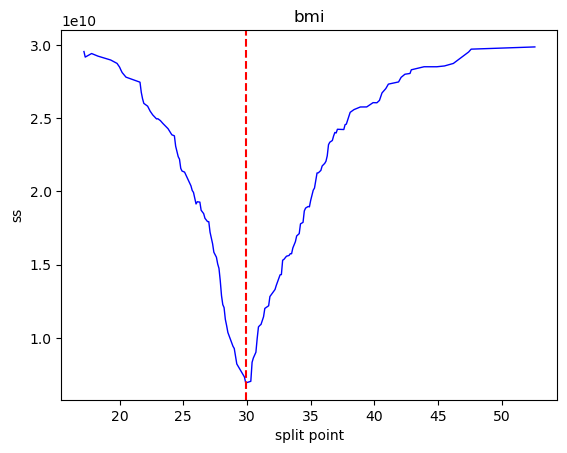

<Figure size 640x480 with 0 Axes>

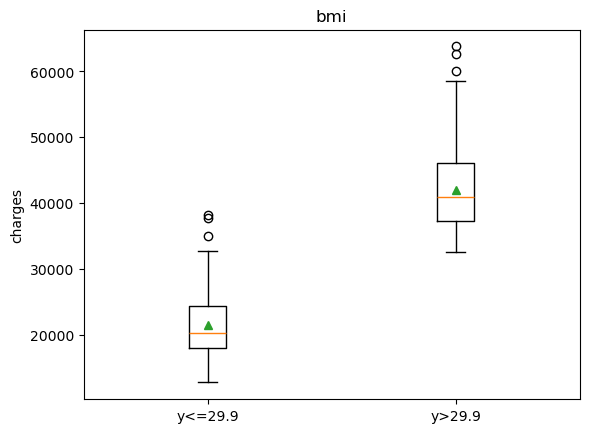

<Figure size 640x480 with 0 Axes>

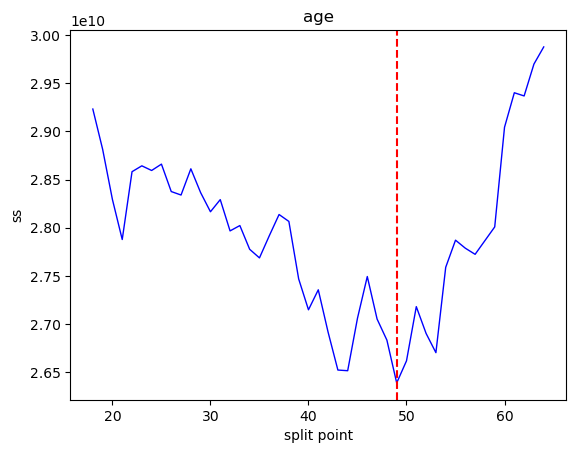

<Figure size 640x480 with 0 Axes>

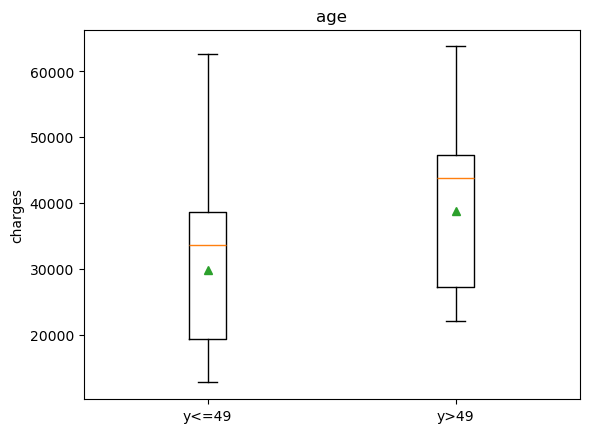

<Figure size 640x480 with 0 Axes>

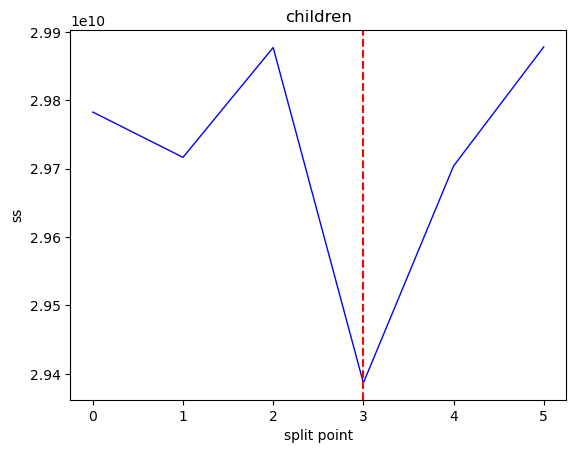

<Figure size 640x480 with 0 Axes>

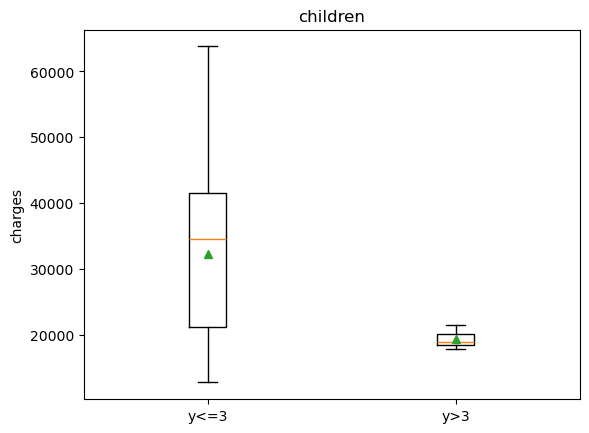

,split_var_name,opt_split,opt_ss
0,bmi,29.9,6.918145e+09
1,age,49.0,2.638722e+10
2,children,3.0,2.938669e+10


Text(0.5, 1.0, 'Comparison of optimal ss for each variable')

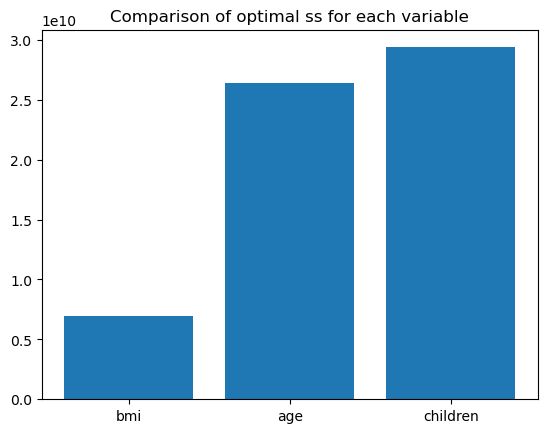

In [ ]:
#calculate optimum for different variables
set_vars = ["bmi", "age", "children"] #try set of these variables

